# Parte 3 — Comparação A vs B e Recomendação (Q4)

## Contexto

A **Central 1746** usa o **modelo A** em produção e avalia o **modelo B** (candidato) para o mesmo problema: classificar o texto do chamado na categoria de serviço correta.

Este notebook compara A e B sobre os **mesmos 5.000 chamados** (`dados/chamados_com_predicoes.csv`) e responde: **devemos trocar de modelo?**

> **Nota:** dados sintéticos — simulam comportamento estatístico de um sistema real.

## Objetivo

1. Comparar desempenho **global** com teste estatístico adequado ao desenho **pareado**.
2. Verificar se a conclusão global se sustenta **por categoria** (trade-offs).
3. Checar se o B melhora os **modos de falha** da auditoria do A (Parte 2).
4. Produzir **recomendação acionável** para gestor não técnico.

## Dados utilizados

| Coluna | Descrição |
|--------|-----------|
| `categoria_real` | Ground truth |
| `pred_modelo_a` / `pred_modelo_b` | Predições |
| `conf_modelo_a` / `conf_modelo_b` | Confiança declarada |
| `texto` | Input (para `texto_len` / faixas da EDA) |

## Conexão com Partes 1 e 2

| Achado anterior | O que checamos aqui |
|-----------------|---------------------|
| Desbalanceamento → olhar por classe | Diferença B−A por categoria |
| Textos curtos pioram o A | Acurácia A vs B por faixa de texto |
| Confusão `esgoto→buraco` (221 casos no A) | O B reduz essa confusão? |
| `conf_modelo_a` não calibra | O B tem confiança mais útil? |

## Decisões metodológicas

| Decisão | Escolha |
|---------|---------|
| Desenho | Pareado (mesmos chamados) |
| Teste global | McNemar (correção de continuidade) |
| Métricas | Acurácia + macro-F1; por classe: acurácia e Δ(B−A) |
| IC | Bootstrap estratificado (B=1000, seed=42, 95%) |
| Figuras | `results/figures/comparacao/` |

## Roteiro

1. Setup e carregamento
2. Comparação global (métricas + IC)
3. Tabela pareada e teste de McNemar
4. Comparação por categoria (trade-offs)
5. Baseline das falhas da Parte 2
6. Calibração da confiança A vs B
7. Recomendação e síntese


## Setup

Imports, caminhos e constantes. Figuras da Parte 3 vão em `results/figures/comparacao/`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.metrics import accuracy_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar

%matplotlib inline

ROOT = Path("..").resolve()
DATA_PATH = ROOT / "dados" / "chamados_com_predicoes.csv"
FIG_DIR = ROOT / "results" / "figures" / "comparacao"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
N_BOOTSTRAP = 1000
CI_LEVEL = 0.95

sns.set_theme(style="whitegrid")


## Carregamento e preparação

Criamos indicadores de acerto para A e B e as faixas de texto da EDA (≤60 / 61–149 / ≥150).


In [2]:
df = pd.read_csv(DATA_PATH)

assert df.shape == (5000, 10)
assert df.isna().sum().sum() == 0
assert df["id_chamado"].is_unique
assert df["conf_modelo_a"].between(0, 1).all()
assert df["conf_modelo_b"].between(0, 1).all()

df["texto_len"] = df["texto"].str.len()
df["acerto_a"] = df["pred_modelo_a"] == df["categoria_real"]
df["acerto_b"] = df["pred_modelo_b"] == df["categoria_real"]
df["faixa_texto"] = pd.cut(
    df["texto_len"],
    bins=[0, 60, 149, np.inf],
    labels=["curto (≤60)", "médio (61–149)", "longo (≥150)"],
    include_lowest=True,
)

LABELS = sorted(df["categoria_real"].unique())

resumo = pd.Series(
    {
        "registros": len(df),
        "acuracia_a": round(df["acerto_a"].mean(), 4),
        "acuracia_b": round(df["acerto_b"].mean(), 4),
        "delta_b_menos_a": round(df["acerto_b"].mean() - df["acerto_a"].mean(), 4),
        "n_categorias": len(LABELS),
    }
)
display(resumo)
display(df[["categoria_real", "pred_modelo_a", "pred_modelo_b", "acerto_a", "acerto_b", "faixa_texto"]].head())


registros          5000.0000
acuracia_a            0.7728
acuracia_b            0.8676
delta_b_menos_a       0.0948
n_categorias          8.0000
dtype: float64

,categoria_real,pred_modelo_a,pred_modelo_b,acerto_a,acerto_b,faixa_texto
0,barulho_perturbacao,barulho_perturbacao,barulho_perturbacao,True,True,médio (61–149)
1,barulho_perturbacao,barulho_perturbacao,barulho_perturbacao,True,True,longo (≥150)
2,iluminacao_publica,iluminacao_publica,iluminacao_publica,True,True,longo (≥150)
3,iluminacao_publica,coleta_lixo,iluminacao_publica,False,True,longo (≥150)
4,coleta_lixo,buraco_via,coleta_lixo,False,True,médio (61–149)


### Interpretação

- Corpus de **5.000** chamados válido para comparação pareada.
- Acurácia bruta: A ≈ **0,773**, B ≈ **0,868** (Δ ≈ **+0,095**) — ponto de partida; IC e teste formal vêm a seguir.
- Mesmas 8 categorias nos dois modelos — comparação justa por classe.

**Próximo passo:** métricas globais com IC e figura A vs B.


## Comparação global — acurácia e macro-F1

Usamos bootstrap **estratificado** por `categoria_real` (B=1000, seed=42) para IC 95% das métricas de cada modelo — o mesmo espírito da Parte 2. O IC é **condicional ao mix de classes observado** (proporções fixas por reamostra).


Bootstrap global B=1000, seed=42…


,modelo,acuracia,acuracia_ic95_low,acuracia_ic95_high,macro_f1,macro_f1_ic95_low,macro_f1_ic95_high
0,A,0.7728,0.7616,0.7844,0.7704,0.7589,0.7835
1,B,0.8676,0.8586,0.8764,0.8516,0.8408,0.8618


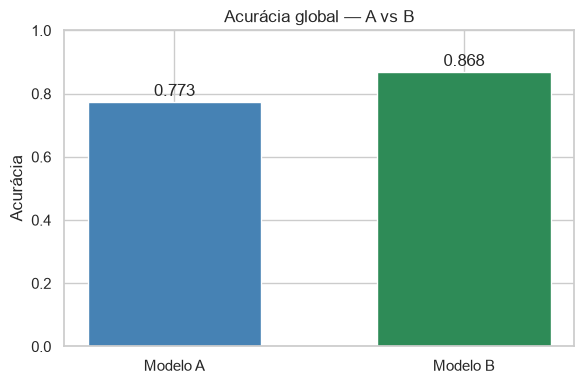

In [3]:
def stratified_resample(df, strata_col, rng):
    parts = []
    for _, group in df.groupby(strata_col, sort=False):
        idx = rng.choice(group.index.to_numpy(), size=len(group), replace=True)
        parts.append(df.loc[idx])
    return pd.concat(parts, ignore_index=True)


def bootstrap_global_metrics(df, labels, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for model, pred_col in [("A", "pred_modelo_a"), ("B", "pred_modelo_b")]:
        y_true = df["categoria_real"]
        y_pred = df[pred_col]
        acc = accuracy_score(y_true, y_pred)
        macro = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
        acc_boot = np.empty(n_boot)
        macro_boot = np.empty(n_boot)
        for b in range(n_boot):
            sample = stratified_resample(df, "categoria_real", rng)
            acc_boot[b] = accuracy_score(sample["categoria_real"], sample[pred_col])
            macro_boot[b] = f1_score(
                sample["categoria_real"],
                sample[pred_col],
                average="macro",
                labels=labels,
                zero_division=0,
            )
        alpha = 1 - CI_LEVEL
        lo, hi = 100 * (alpha / 2), 100 * (1 - alpha / 2)
        rows.append(
            {
                "modelo": model,
                "acuracia": acc,
                "acuracia_ic95_low": np.percentile(acc_boot, lo),
                "acuracia_ic95_high": np.percentile(acc_boot, hi),
                "macro_f1": macro,
                "macro_f1_ic95_low": np.percentile(macro_boot, lo),
                "macro_f1_ic95_high": np.percentile(macro_boot, hi),
            }
        )
    return pd.DataFrame(rows)


print(f"Bootstrap global B={N_BOOTSTRAP}, seed={RANDOM_SEED}…")
global_tbl = bootstrap_global_metrics(df, LABELS)
display(global_tbl.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
accs = global_tbl["acuracia"].values
ax.bar(x, accs, color=["steelblue", "seagreen"], width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(["Modelo A", "Modelo B"])
ax.set_ylim(0, 1)
ax.set_ylabel("Acurácia")
ax.set_title("Acurácia global — A vs B")
for i, v in enumerate(accs):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_acuracia_global_a_vs_b.png", dpi=200, bbox_inches="tight")
plt.show()


### Interpretação

- B supera A em **acurácia** e **macro-F1**, com ICs que **não se sobrepõem** de forma relevante — vantagem estável nesta amostra.
- O ganho em macro-F1 indica melhoria também quando classes são tratadas igualmente (importante sob desbalanceamento).

**Próximo passo:** tabela pareada e McNemar.


## Tabela pareada e teste de McNemar

As predições A e B são sobre os **mesmos chamados** → amostras **dependentes**. Um teste para amostras independentes (ex.: dois proporções não pareadas) seria **incorreto**.

**McNemar** usa as **discordâncias**:
- só B acerta (A erra)
- só A acerta (B erra)

**H0:** P(só B acerta) = P(só A acerta).  
Se rejeitamos H0 com mais casos “só B acerta”, há evidência de que B é melhor no desenho pareado.


In [4]:
ambos_acertam = int((df["acerto_a"] & df["acerto_b"]).sum())
so_a = int((df["acerto_a"] & ~df["acerto_b"]).sum())  # A acerta, B erra
so_b = int((~df["acerto_a"] & df["acerto_b"]).sum())  # A erra, B acerta
ambos_erram = int((~df["acerto_a"] & ~df["acerto_b"]).sum())

pareada = pd.DataFrame(
    {
        "outcome": ["ambos_acertam", "so_A_acerta", "so_B_acerta", "ambos_erram"],
        "n": [ambos_acertam, so_a, so_b, ambos_erram],
        "pct": np.array([ambos_acertam, so_a, so_b, ambos_erram]) / len(df) * 100,
    }
)
display(pareada.round(2))

# Contigência 2x2: linhas = A (certo/errado), colunas = B (certo/errado)
contingency = np.array(
    [
        [ambos_acertam, so_a],  # A certo: B certo | B errado
        [so_b, ambos_erram],    # A errado: B certo | B errado
    ]
)
print("Contingência [[A✓B✓, A✓B✗], [A✗B✓, A✗B✗]]:")
display(pd.DataFrame(contingency, index=["A_certo", "A_errado"], columns=["B_certo", "B_errado"]))

result = mcnemar(contingency, exact=False, correction=True)
print(f"McNemar (com correção): statistic={result.statistic:.4f}, p-value={result.pvalue:.4e}")
print(f"Discordâncias: só_B={so_b}, só_A={so_a}, razão só_B/só_A={so_b / so_a:.3f}")


,outcome,n,pct
0,ambos_acertam,3347,66.94
1,so_A_acerta,517,10.34
2,so_B_acerta,991,19.82
3,ambos_erram,145,2.90


Contingência [[A✓B✓, A✓B✗], [A✗B✓, A✗B✗]]:


,B_certo,B_errado
A_certo,3347,517
A_errado,991,145


McNemar (com correção): statistic=148.3614, p-value=3.9549e-34
Discordâncias: só_B=991, só_A=517, razão só_B/só_A=1.917


### Interpretação (McNemar)

- Discordâncias: **só B acerta ≈ 991** vs **só A acerta ≈ 517** — B recupera bem mais erros do A do que o contrário.
- **p-valor ≪ 0,001** → rejeitamos H0: a diferença pareada é estatisticamente significativa a favor do B.
- McNemar **não** mede o tamanho do ganho (magnitude); a magnitude vem da diferença de acurácia (~9,5 p.p.) e das análises por categoria.

**Próximo passo:** trade-offs por categoria.


## Comparação por categoria — trade-offs

Para cada classe: acurácia A e B, diferença Δ = B − A, e IC 95% bootstrap da diferença (estratificado).


Bootstrap Δ por categoria B=1000…


,categoria,support,acuracia_a,acuracia_b,delta_b_a,delta_ic95_low,delta_ic95_high
6,poda_arvore,458,0.775,0.526,-0.249,-0.308,-0.186
4,estacionamento_irregular,437,0.826,0.897,0.071,0.025,0.121
7,sinalizacao,227,0.797,0.894,0.097,0.026,0.163
1,buraco_via,908,0.817,0.917,0.100,0.069,0.133
5,iluminacao_publica,1143,0.793,0.898,0.105,0.073,0.133
0,barulho_perturbacao,400,0.775,0.880,0.105,0.055,0.152
2,coleta_lixo,806,0.806,0.917,0.110,0.078,0.143
3,esgoto_vazamento,621,0.578,0.889,0.311,0.264,0.357


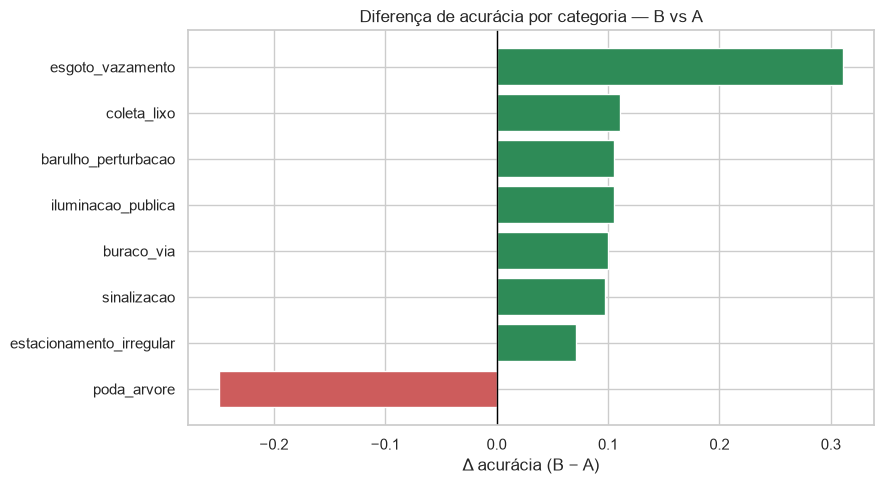

In [5]:
def bootstrap_delta_by_category(df, labels, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    rows = []
    # point estimates
    for lab in labels:
        m = df["categoria_real"] == lab
        acc_a = df.loc[m, "acerto_a"].mean()
        acc_b = df.loc[m, "acerto_b"].mean()
        rows.append(
            {
                "categoria": lab,
                "support": int(m.sum()),
                "acuracia_a": acc_a,
                "acuracia_b": acc_b,
                "delta_b_a": acc_b - acc_a,
            }
        )
    point = pd.DataFrame(rows)

    deltas = {lab: np.empty(n_boot) for lab in labels}
    for b in range(n_boot):
        sample = stratified_resample(df, "categoria_real", rng)
        for lab in labels:
            m = sample["categoria_real"] == lab
            deltas[lab][b] = (
                sample.loc[m, "acerto_b"].mean() - sample.loc[m, "acerto_a"].mean()
            )

    alpha = 1 - CI_LEVEL
    lo, hi = 100 * (alpha / 2), 100 * (1 - alpha / 2)
    point["delta_ic95_low"] = [np.percentile(deltas[lab], lo) for lab in labels]
    point["delta_ic95_high"] = [np.percentile(deltas[lab], hi) for lab in labels]
    return point.sort_values("delta_b_a")


print(f"Bootstrap Δ por categoria B={N_BOOTSTRAP}…")
cat_delta = bootstrap_delta_by_category(df, LABELS)
display(cat_delta.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["indianred" if d < 0 else "seagreen" for d in cat_delta["delta_b_a"]]
ax.barh(cat_delta["categoria"], cat_delta["delta_b_a"], color=colors)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Δ acurácia (B − A)")
ax.set_title("Diferença de acurácia por categoria — B vs A")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_delta_acuracia_por_categoria.png", dpi=200, bbox_inches="tight")
plt.show()


### Interpretação (por categoria)

- B **melhora** em 7 das 8 categorias (descritivo; sem 8 testes formais — evitamos multiplicidade); o maior ganho é **`esgoto_vazamento`** (Δ ≈ **+0,31**), alinhado à falha crítica da Parte 2.
- **Trade-off crítico:** **`poda_arvore`** — Δ ≈ **−0,25** (A ~0,78 → B ~0,53). A conclusão global **não** se sustenta nessa classe.
- Implicação: troca total é defensável no agregado, mas exige **mitigação** para poda (monitoramento / revisão humana / híbrido).

**Próximo passo:** checar explicitamente os modos de falha da auditoria do A.


## Baseline das falhas da Parte 2

A auditoria do A destacou: (1) confusão `esgoto_vazamento → buraco_via`; (2) textos curtos com acurácia ~0,59.


,modo_falha,modelo_a,modelo_b,reducao
0,esgoto_vazamento → buraco_via,221,13,208


,faixa_texto,n,acuracia_a,acuracia_b,delta_b_a
0,curto (≤60),1422,0.595,0.854,0.259
1,médio (61–149),472,0.867,0.898,0.032
2,longo (≥150),3106,0.840,0.869,0.029


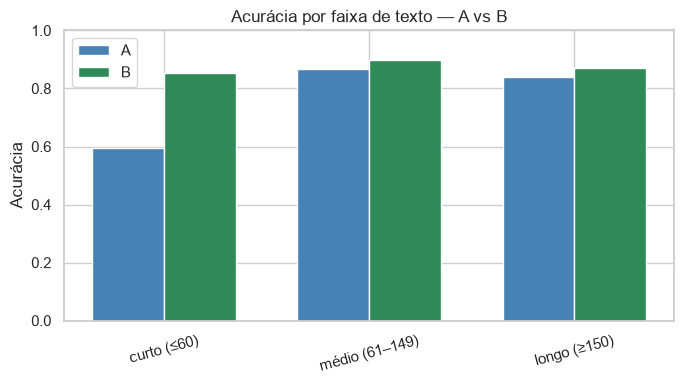

In [6]:
def count_confusion(pred_col, real, pred):
    return int(((df["categoria_real"] == real) & (df[pred_col] == pred)).sum())


baseline = pd.DataFrame(
    [
        {
            "modo_falha": "esgoto_vazamento → buraco_via",
            "modelo_a": count_confusion("pred_modelo_a", "esgoto_vazamento", "buraco_via"),
            "modelo_b": count_confusion("pred_modelo_b", "esgoto_vazamento", "buraco_via"),
        }
    ]
)
baseline["reducao"] = baseline["modelo_a"] - baseline["modelo_b"]
display(baseline)

faixa_cmp = (
    df.groupby("faixa_texto", observed=True)
    .agg(
        n=("acerto_a", "size"),
        acuracia_a=("acerto_a", "mean"),
        acuracia_b=("acerto_b", "mean"),
    )
    .reset_index()
)
faixa_cmp["delta_b_a"] = faixa_cmp["acuracia_b"] - faixa_cmp["acuracia_a"]
display(faixa_cmp.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(faixa_cmp))
w = 0.35
ax.bar(x - w / 2, faixa_cmp["acuracia_a"], w, label="A", color="steelblue")
ax.bar(x + w / 2, faixa_cmp["acuracia_b"], w, label="B", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(faixa_cmp["faixa_texto"].astype(str), rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel("Acurácia")
ax.set_title("Acurácia por faixa de texto — A vs B")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_acuracia_por_faixa_texto_a_vs_b.png", dpi=200, bbox_inches="tight")
plt.show()


### Interpretação (baseline Parte 2)

- Confusão **esgoto→buraco**: **221 → 13** (−208) — o B ataca o principal modo de falha sanitário/operacional do A.
- Textos **curtos**: A ≈ **0,59** → B ≈ **0,85** — fecha o gap da EDA/auditoria.
- Em textos longos a vantagem do B é menor, mas ainda positiva.

**Próximo passo:** calibração da confiança.


## Calibração — `conf_modelo_a` vs `conf_modelo_b`

Na Parte 2, a confiança do A **não** discriminava acerto/erro. Aqui comparamos com o B.


,modelo,outcome,conf_media
0,A,acerto,0.923
1,A,erro,0.923
2,B,acerto,0.846
3,B,erro,0.553


,conf_bin_b,n,taxa_erro
0,"(0.499, 0.6]",234,0.718
1,"(0.6, 0.7]",428,0.306
2,"(0.7, 0.8]",909,0.098
3,"(0.8, 0.9]",1673,0.018
4,"(0.9, 1.0]",1505,0.004


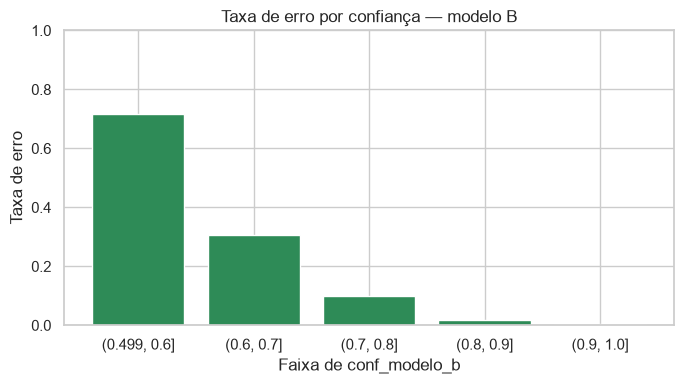

In [7]:
calib_summary = pd.DataFrame(
    {
        "modelo": ["A", "A", "B", "B"],
        "outcome": ["acerto", "erro", "acerto", "erro"],
        "conf_media": [
            df.loc[df["acerto_a"], "conf_modelo_a"].mean(),
            df.loc[~df["acerto_a"], "conf_modelo_a"].mean(),
            df.loc[df["acerto_b"], "conf_modelo_b"].mean(),
            df.loc[~df["acerto_b"], "conf_modelo_b"].mean(),
        ],
    }
)
display(calib_summary.round(3))

df["conf_bin_b"] = pd.cut(
    df["conf_modelo_b"], bins=np.arange(0.5, 1.01, 0.1), include_lowest=True
)
err_by_conf_b = (
    df.groupby("conf_bin_b", observed=True)
    .agg(n=("acerto_b", "size"), taxa_erro=("acerto_b", lambda x: (~x).mean()))
    .reset_index()
)
display(err_by_conf_b.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(err_by_conf_b["conf_bin_b"].astype(str), err_by_conf_b["taxa_erro"], color="seagreen")
ax.set_ylabel("Taxa de erro")
ax.set_xlabel("Faixa de conf_modelo_b")
ax.set_title("Taxa de erro por confiança — modelo B")
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_confianca_vs_erro_modelo_b.png", dpi=200, bbox_inches="tight")
plt.show()


### Interpretação (calibração)

- **A:** confiança média ~**0,92** em acertos **e** erros — inútil para triagem.
- **B:** confiança ~**0,85** quando acerta vs ~**0,55** quando erra; taxa de erro cai forte com a confiança (ex.: >0,9 → erro ~**0,4%**).
- **Impacto:** com o B, dá para usar limiar de confiança para **fila de revisão humana** (ex.: revisar predições com conf < 0,7), inclusive como mitigação parcial em `poda_arvore`.

**Próximo passo:** recomendação final.


## Recomendação para gestor (não técnico)

Recomendamos **substituir o modelo A pelo modelo B** na Central 1746. Na amostra de 5.000 chamados, o B acerta cerca de **87%** dos casos frente a **77%** do A (diferença estatisticamente significativa no teste pareado). O B também corrige falhas graves do A — por exemplo, confunde bem menos esgoto com buraco e melhora muito o desempenho em textos curtos. **Risco:** na categoria de poda de árvore o B piora (acurácia cai de ~78% para ~53%). **Mitigação:** ao colocar o B em produção, monitorar semanalmente a poda de árvore e, se necessário, manter revisão humana ou regra híbrida só para essa categoria até o modelo ser ajustado. **Próximo passo:** rollout com painel das oito categorias e alerta se a poda cair abaixo do nível atual do A.

### Síntese analítica

| Pergunta | Resposta baseada nos dados |
|----------|----------------------------|
| B é melhor no global? | **Sim** (acc ~0,87 vs 0,77; McNemar p ≪ 0,001) |
| Sustenta por categoria? | **Quase** — piora só em `poda_arvore` |
| Corrige falhas da Parte 2? | **Sim** — esgoto→buraco e textos curtos |
| Confiança útil? | **Só no B** |

### Limitações

- Dados **sintéticos** — validar em produção antes do deploy definitivo.
- McNemar testa discordâncias, não o tamanho do efeito (reportamos Δ e IC à parte).
- Comparação por categoria usa Δ pontual + IC bootstrap, **sem** correção de multiplicidade — "7 de 8" é descritivo, não teste múltiplo formal.
- Regressão em poda (~458 chamados) tem impacto operacional real — não ignorar na troca.

### Próximo passo no repositório

Atualizar o `README.md` com abordagem, como reproduzir e o **mesmo parágrafo** de recomendação no sumário executivo.
